Loaded X_stratified with shape: (2859, 55)

STRATIFICATION DISTRIBUTION VISUALIZATIONS


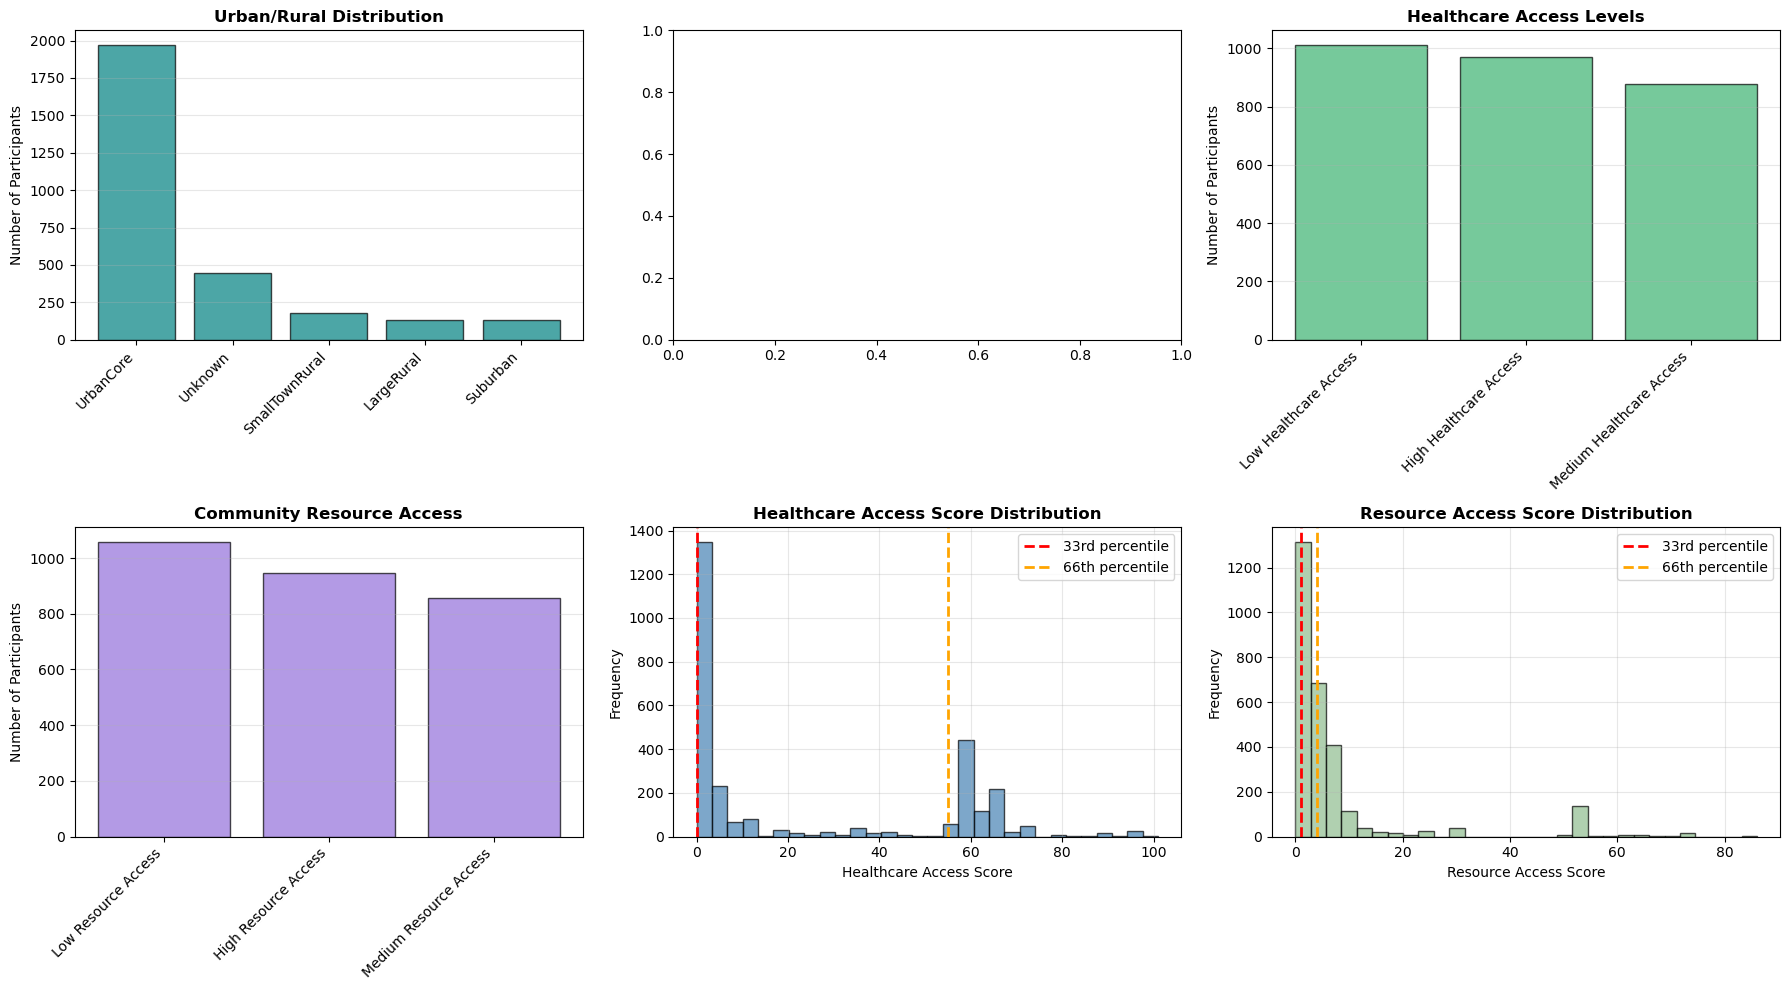


Saved stratification distribution visualizations

CROSS-TABULATIONS OF STRATIFICATION VARIABLES

Urban/Rural × Healthcare Access:
healthcare_access_category  High Healthcare Access  Low Healthcare Access  \
urban_rural_category                                                        
LargeRural                                       0                     29   
SmallTownRural                                   0                    153   
Suburban                                         0                    124   
Unknown                                          0                    444   
UrbanCore                                      969                    261   
All                                            969                   1011   

healthcare_access_category  Medium Healthcare Access   All  
urban_rural_category                                        
LargeRural                                       104   133  
SmallTownRural                                    26   179  
Suburban

In [ ]:
# Load the stratified dataset for downstream analysis in this cell
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

X_stratified = pd.read_csv("/edata/obdw/sandwich_analysis_data/X_basic_plus_clin_sdh_location_stratified.csv")
print(f"Loaded X_stratified with shape: {X_stratified.shape}")

# Default output folder if not already defined in another cell
if 'out_folder' not in globals():
    out_folder = "./"

# Compute tertiles locally if not already defined
if 'healthcare_tertiles' not in globals() and 'healthcare_access_score' in X_stratified.columns:
    healthcare_tertiles = X_stratified['healthcare_access_score'].dropna().quantile([1/3, 2/3])

if 'resource_tertiles' not in globals() and 'resource_access_score' in X_stratified.columns:
    resource_tertiles = X_stratified['resource_access_score'].dropna().quantile([1/3, 2/3])

# VISUALIZATION: Stratification distributions
print("\n" + "="*80)
print("STRATIFICATION DISTRIBUTION VISUALIZATIONS")
print("="*80)

# Create figure with stratification distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Urban/Rural distribution
if 'urban_rural_category' in X_stratified.columns:
    ax = axes[0, 0]
    category_counts = X_stratified['urban_rural_category'].value_counts()
    ax.bar(range(len(category_counts)), category_counts.values, color='teal', alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(category_counts)))
    ax.set_xticklabels(category_counts.index, rotation=45, ha='right')
    ax.set_title('Urban/Rural Distribution', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Participants')
    ax.grid(True, alpha=0.3, axis='y')

# Plot 2: SVI category distribution
if 'svi_category' in X_stratified.columns:
    ax = axes[0, 1]
    category_counts = X_stratified['svi_category'].value_counts()
    ax.bar(range(len(category_counts)), category_counts.values, color='coral', alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(category_counts)))
    ax.set_xticklabels(category_counts.index, rotation=45, ha='right')
    ax.set_title('SVI Vulnerability Levels', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Participants')
    ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Healthcare access distribution
if 'healthcare_access_category' in X_stratified.columns:
    ax = axes[0, 2]
    category_counts = X_stratified['healthcare_access_category'].value_counts()
    ax.bar(range(len(category_counts)), category_counts.values, color='mediumseagreen', alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(category_counts)))
    ax.set_xticklabels(category_counts.index, rotation=45, ha='right')
    ax.set_title('Healthcare Access Levels', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Participants')
    ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Resource access distribution
if 'resource_access_category' in X_stratified.columns:
    ax = axes[1, 0]
    category_counts = X_stratified['resource_access_category'].value_counts()
    ax.bar(range(len(category_counts)), category_counts.values, color='mediumpurple', alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(category_counts)))
    ax.set_xticklabels(category_counts.index, rotation=45, ha='right')
    ax.set_title('Community Resource Access', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Participants')
    ax.grid(True, alpha=0.3, axis='y')

# Plot 5: Healthcare access score histogram
if 'healthcare_access_score' in X_stratified.columns:
    ax = axes[1, 1]
    data = X_stratified['healthcare_access_score'].dropna()
    ax.hist(data, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    if 'healthcare_tertiles' in globals() and len(healthcare_tertiles) >= 2:
        ax.axvline(healthcare_tertiles.iloc[0], color='red', linestyle='--', linewidth=2, label='33rd percentile')
        ax.axvline(healthcare_tertiles.iloc[1], color='orange', linestyle='--', linewidth=2, label='66th percentile')
    ax.set_title('Healthcare Access Score Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Healthcare Access Score')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Plot 6: Resource access score histogram
if 'resource_access_score' in X_stratified.columns:
    ax = axes[1, 2]
    data = X_stratified['resource_access_score'].dropna()
    ax.hist(data, bins=30, color='darkseagreen', alpha=0.7, edgecolor='black')
    if 'resource_tertiles' in globals() and len(resource_tertiles) >= 2:
        ax.axvline(resource_tertiles.iloc[0], color='red', linestyle='--', linewidth=2, label='33rd percentile')
        ax.axvline(resource_tertiles.iloc[1], color='orange', linestyle='--', linewidth=2, label='66th percentile')
    ax.set_title('Resource Access Score Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Resource Access Score')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(out_folder + "stratification_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved stratification distribution visualizations")

# CROSS-TABULATION OF KEY STRATIFICATIONS
print("\n" + "="*80)
print("CROSS-TABULATIONS OF STRATIFICATION VARIABLES")
print("="*80)

if 'urban_rural_category' in X_stratified.columns and 'svi_category' in X_stratified.columns:
    print("\nUrban/Rural × SVI Vulnerability:")
    cross_tab = pd.crosstab(X_stratified['urban_rural_category'], X_stratified['svi_category'], margins=True)
    print(cross_tab)

if 'urban_rural_category' in X_stratified.columns and 'healthcare_access_category' in X_stratified.columns:
    print("\nUrban/Rural × Healthcare Access:")
    cross_tab = pd.crosstab(X_stratified['urban_rural_category'], X_stratified['healthcare_access_category'], margins=True)
    print(cross_tab)

if 'svi_category' in X_stratified.columns and 'healthcare_access_category' in X_stratified.columns:
    print("\nSVI Vulnerability × Healthcare Access:")
    cross_tab = pd.crosstab(X_stratified['svi_category'], X_stratified['healthcare_access_category'], margins=True)
    print(cross_tab)

print("\n" + "="*80)
print("STRATIFICATION VARIABLES CREATION COMPLETE")
print("="*80)
print("\nRecommended analysis approaches:")
print("1. Include stratification variables as fixed effects in mixed models")
print("2. Test interactions between stratification variables and predictors")
print("3. Conduct sensitivity analyses within each stratification group")
print("4. Always include cluster as a random effect to account for geographic clustering")